## Amazon E-commerce business analytics

### 📌 Problem Statement
In a competitive e-commerce environment, understanding customer purchasing behavior, pricing trends, and revenue drivers is critical.
This project aims to:
- Analyze sales and pricing patterns
- Identify top-performing product categories
- Understand customer purchase behavior
- Provide actionable business insights to improve revenue and strategy

### NOTEBOOK SETUP

Importing libraries

In [62]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

Creating Dataframe

In [ ]:
df =pd.read_csv('amazon_ecommerce_1M.csv')
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


DataFrame Informaion

In [46]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  str    
 1   product_id          1000000 non-null  str    
 2   category            1000000 non-null  str    
 3   subcategory         1000000 non-null  str    
 4   brand               1000000 non-null  str    
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  str    
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  str    
 14  shipping_time_days  1000000 non-null  int64  
 15  location            1000000

(1000000, 20)

### DATA CLEANING AND PREPROCESSING

Finding null values and dropping them(if any)

In [47]:
df.isnull().sum()

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

Dropping duplicates

In [48]:
df.drop_duplicates(inplace=True)
df.shape

(1000000, 20)

Feature Engineering

In [49]:
# Convert date column
df['purchase_date'] = pd.to_datetime(df['purchase_date'], errors='coerce')

# Extract features
df['year'] = df['purchase_date'].dt.year
df['month'] = df['purchase_date'].dt.month

# Create target variable (Business logic)
df['high_value_order'] = (df['price'] > df['price'].median()).astype(int)

### EXPLORATORY DATA ANALYSIS

Category Distribution

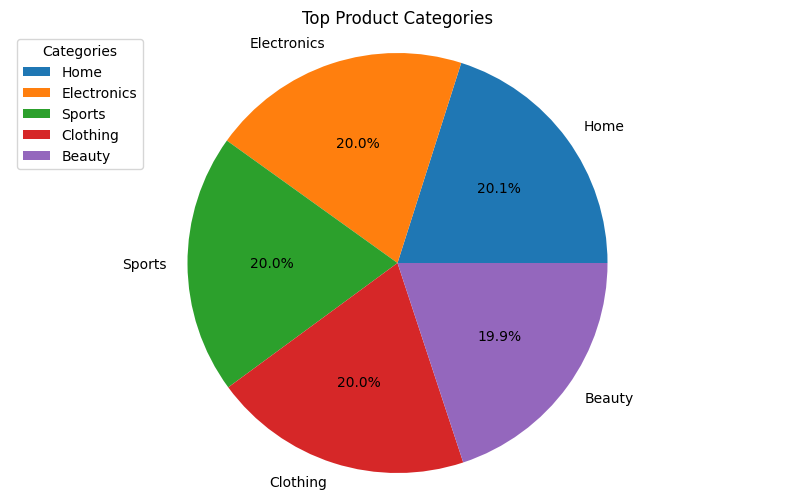

In [50]:
top_categories = df['category'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(top_categories, labels=top_categories.index, autopct='%1.1f%%')
plt.title("Top Product Categories")
plt.axis('equal')
plt.legend(title="Categories", loc="upper left")
plt.show()

### 📊 Insights:
- The distribution of products across categories is almost uniform, with each category contributing around 20% of the total, indicating a well-balanced product portfolio.
- No single category dominates the dataset, suggesting that the platform offers diverse product options across multiple segments.
- Slight variations (e.g., Home being marginally higher) indicate minor differences in product availability but not significant enough to impact overall balance.
- The evenly spread distribution reduces dependency on a single category, which helps in minimizing business risk and ensures stable revenue streams.

Price VS Category

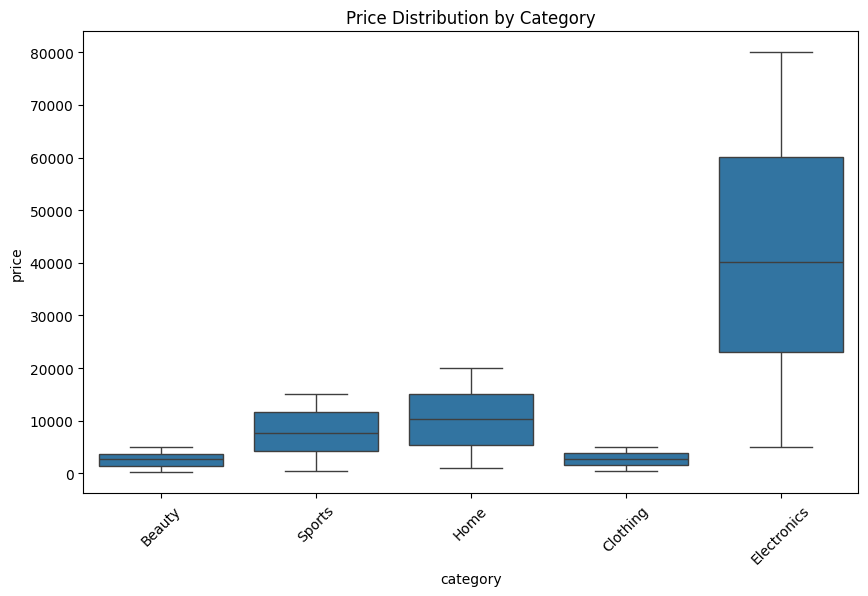

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.sample(5000), x='category', y='price')
plt.xticks(rotation=45)
plt.title("Price Distribution by Category")
plt.show()

### 📊 Insights:
- Electronics category has the highest price range and variability, indicating the presence of both mid-range and premium products.
- Home and Sports categories show moderate price ranges, suggesting a mix of affordable and mid-tier products.
- Clothing and Beauty categories have relatively lower and more consistent price distributions, indicating standardized and budget-friendly pricing.
- The presence of outliers in categories like Electronics suggests premium or luxury products that significantly exceed average prices.

Orders by sub-category

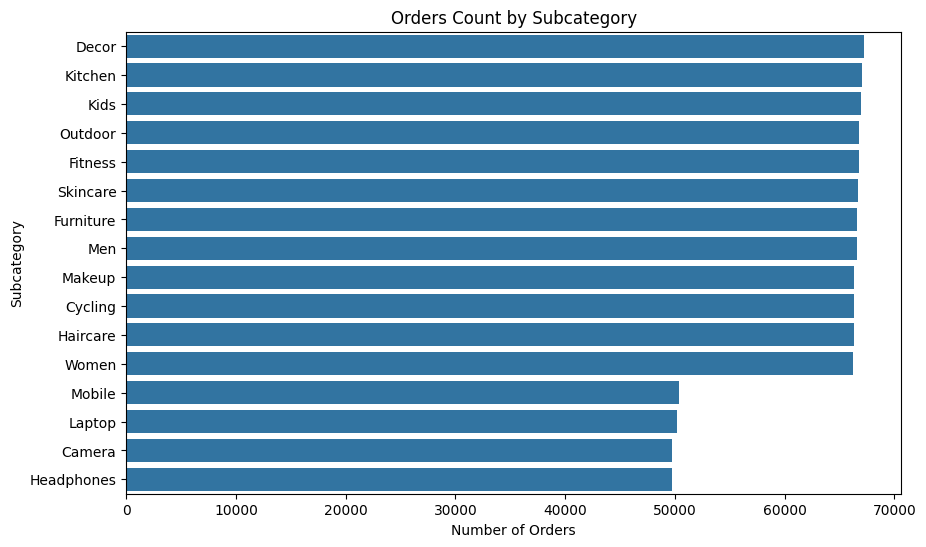

In [52]:
subcategory_counts = df['subcategory'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=subcategory_counts.values,
    y=subcategory_counts.index
)
plt.title("Orders Count by Subcategory")
plt.xlabel("Number of Orders")
plt.ylabel("Subcategory")
plt.show()

### 📊 Insights:

- Most subcategories have a similar number of orders (~65k–70k), indicating a balanced distribution of demand across different product types.
- Subcategories like Decor, Kitchen, and Kids slightly lead in order volume, suggesting higher customer interest in home and lifestyle products.
- Electronics-related subcategories such as Mobile, Laptop, Camera, and Headphones show comparatively lower order counts, indicating either higher pricing or less frequent purchases.
- The relatively uniform distribution across subcategories suggests that customer demand is well-diversified, reducing dependency on a single product segment.

Revenue Analysis

In [53]:
total_revenue = df['final_price'].sum()
avg_order_value = df['final_price'].mean()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)

Total Revenue: 9938876984.900002
Average Order Value: 9938.876984900002


Revenue by category

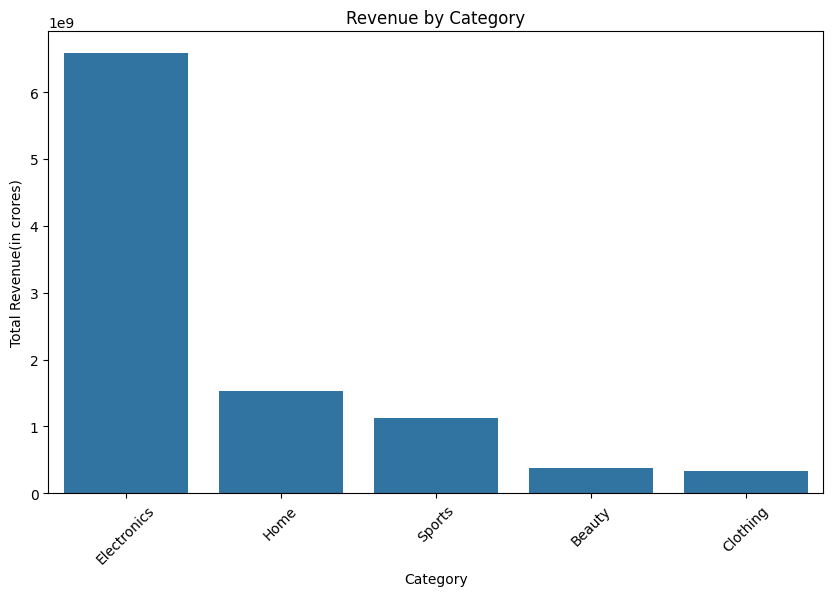

In [54]:
revenue_category = df.groupby('category')['final_price'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(
    x=revenue_category.index,
    y=revenue_category.values
)
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue(in crores)")
plt.xticks(rotation=45)
plt.show()

### 📊 Insights:

- Electronics category generates the highest revenue by a significant margin, making it the primary revenue driver for the business.
- Home and Sports categories contribute moderate revenue, indicating consistent demand but lower ticket size compared to Electronics.
- Beauty and Clothing categories generate comparatively lower revenue, suggesting lower pricing or smaller purchase value per transaction.
- The revenue distribution is highly skewed, indicating strong dependence on the Electronics category for overall business performance.

Monthly Sales Trend

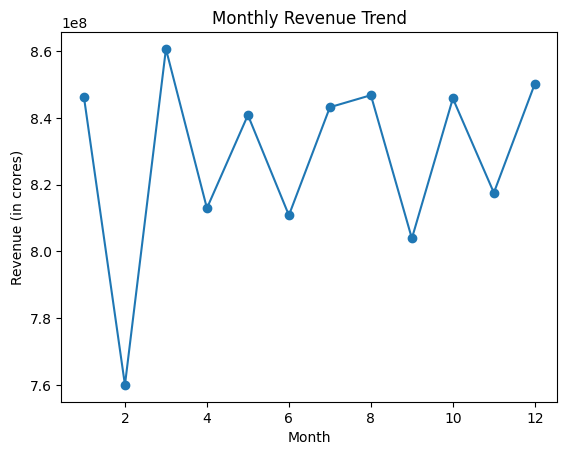

In [55]:
monthly_rev = df.groupby('month')['final_price'].sum()
monthly_rev.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (in crores)")
plt.show()

### 📊 Insights:

- Revenue remains relatively stable throughout the year, indicating consistent sales performance without extreme fluctuations.
- A noticeable dip occurs around month 2, suggesting a potential seasonal slowdown or post-holiday decline in sales.
- Revenue peaks in months like 3, 8, 10, and 12, indicating possible high-demand periods or successful promotional campaigns.
- The overall trend shows minor fluctuations rather than sharp spikes, suggesting a mature and stable market with steady demand.

Revenue by Payment

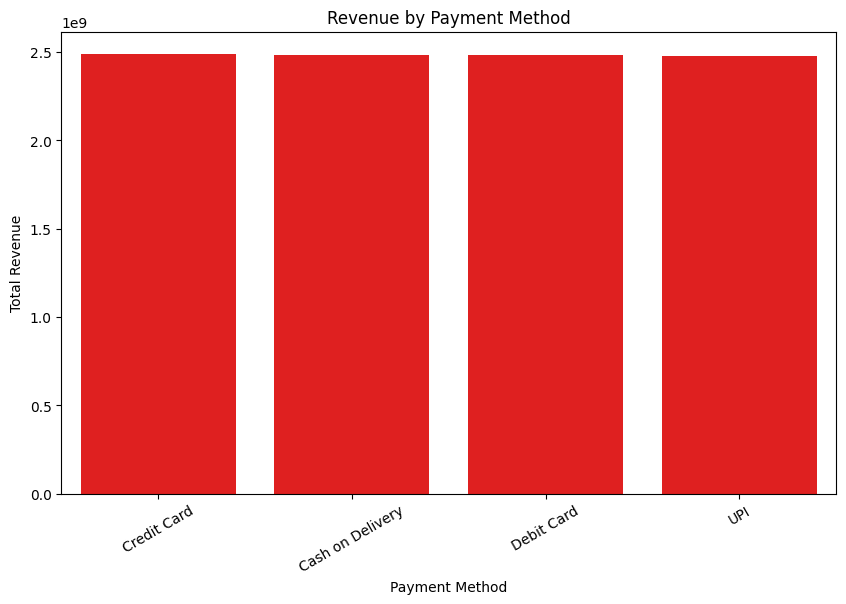

In [56]:
revenue_payment = df.groupby('payment_method')['final_price'].sum().sort_values(ascending=False)
# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=revenue_payment.index,
    y=revenue_payment.values,
    color='red'
)
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

### 📊 Insights:

- Revenue contribution is almost identical across all payment methods, indicating no single payment mode dominates in terms of revenue generation.
- Credit Card, Debit Card, UPI, and Cash on Delivery all generate nearly equal revenue, suggesting a balanced customer preference across payment options.
- The uniform revenue distribution implies that customers using different payment methods have similar purchasing behavior and spending patterns.
- This balance ensures business stability, as revenue is not dependent on any single payment channel.

Payment method

payment_method
Cash on Delivery    250409
Credit Card         250282
UPI                 249963
Debit Card          249346
Name: count, dtype: int64


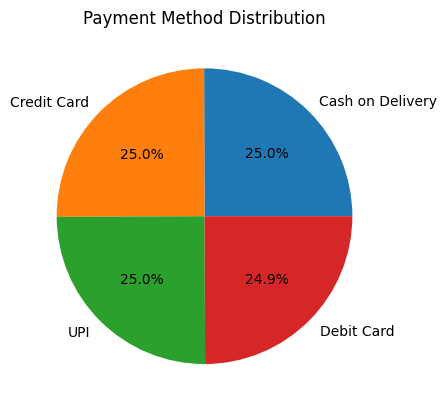

In [57]:
payment_method_counts = df['payment_method'].value_counts()
print(payment_method_counts)
plt.pie(payment_method_counts, labels=payment_method_counts.index, autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

### 📊 Insights:
- Payment methods are almost evenly distributed across all options, indicating no strong preference for a single payment mode among customers.
- Cash on Delivery, UPI, Credit Card, and Debit Card each contribute roughly 25%, showing a balanced mix of digital and offline payment behavior.
- The continued use of Cash on Delivery highlights the importance of trust and flexibility in payment options for customers.

Correlation matrix

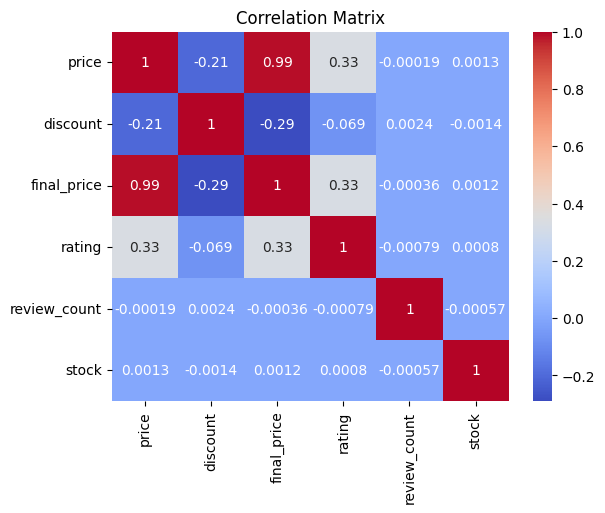

In [58]:
corr = df[['price', 'discount', 'final_price', 'rating', 'review_count', 'stock']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### 📊 Correlation Insights:
- There is a very strong positive correlation (0.99) between price and final_price, indicating that product pricing is the primary driver of revenue.
- Discount shows a negative correlation (-0.29) with final_price, meaning higher discounts reduce overall revenue per product.
- Rating has a moderate positive correlation (~0.33) with price, suggesting that higher-priced products tend to have better perceived quality.
- Review_count and stock show almost no correlation with other variables, indicating that customer demand and inventory levels are not strongly aligned with pricing strategies.

Model building for predicting "IF A PRODUCT WILL BE RETURNED OR NOT"

Accuracy: 0.815005
Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.89      0.89    176644
        True       0.23      0.25      0.24     23356

    accuracy                           0.82    200000
   macro avg       0.57      0.57      0.57    200000
weighted avg       0.82      0.82      0.82    200000



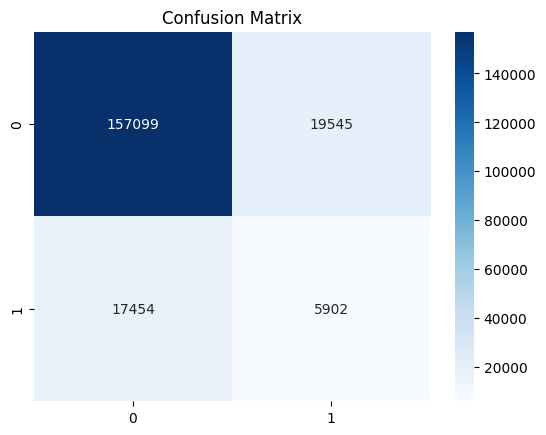

In [59]:
# Copy dataset
df_ml = df.copy()

# Drop unnecessary columns
df_ml = df_ml.drop(['product_id','user_id','seller_id','purchase_date','delivery_status'], axis=1)

#Encoding categorical value
categorical_cols = ['category', 'subcategory', 'brand', 'location', 'device', 'payment_method']
for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

# Define features and target
X = df_ml.drop('is_returned', axis=1)
y = df_ml['is_returned']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # 🔥 IMPORTANT
    random_state=42
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### 📊 Model Performance Insights:

- The model achieves an overall accuracy of ~81.5%, indicating good performance in predicting the majority class (non-returned products).
- The model performs very well for non-returned items (False class) with high precision (0.90) and recall (0.89), meaning it correctly identifies most successful deliveries.
- However, performance for returned items (True class) is significantly lower, with precision (0.23) and recall (0.25), indicating difficulty in identifying product returns.
- The confusion matrix shows a high number of false negatives (returns predicted as non-returns), suggesting the model struggles to capture return behavior effectively.

Model building to predict FINAL PRICE

In [68]:

# Copy dataset
df_cpy = df.copy()

# Drop leakage columns
df_cpy = df_cpy.drop(['final_price'], axis=1)

# Select useful features
features = ['discount', 'rating', 'review_count', 'stock', 'seller_rating','price']
X = df_cpy[features]
y = df['final_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape)

MAE: 1168.9678610933809
R2 Score: 0.980398883073983
MAPE: 0.5109210754592918


### 📊 Insights:

- The model has a low R² score of 0.18, meaning it explains only about 18% of the variation in final price.
- The average error (MAE) is around 8967, which is relatively high, indicating poor prediction accuracy.This is because the price of product varies hugely.
- This shows that features like discount, rating, review_count, and stock are not strong predictors of final price.
- The results confirm that final price mainly depends on the base price, which was removed to avoid data leakage.